In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
!pip install groq pandas scikit-learn matplotlib


In [ ]:
import os

os.environ["GROQ_API_KEY"] = "GROQ_API_KEY"

GROQ_API_KEY = os.environ["GROQ_API_KEY"]

print("Groq API key loaded!")

Groq API key loaded!


In [ ]:
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

print("Groq client created successfully!")


Groq client created successfully!


In [ ]:
import pandas as pd

df = pd.read_excel("/content/Predict_with_this.xlsx")

df.head()

,Sentence_IT,sentence,intent,X_start,Z_depth,F_rate,Cut_type_en,Cut_type_it,gcode_true
0,Posiziona la mola all'inizio della guida a X10,Position the grinding wheel at the start of th...,pure_positioning,10.0,NaN,NaN,NaN,NaN,G00 X10
1,Rimuovi il materiale fino al punto X20 Z-5 con...,Remove material up to point X20 Z-5 with a lig...,grind_linear,20.0,NaN,20.0,light cut,taglio leggero,G01 X20 F_medium
2,Ritorno alla posizione iniziale,Return to the home position,homing,NaN,NaN,NaN,NaN,NaN,G28
3,Spostati lentamente a X15 Z-3,Move slowly to X15 Z-3,grind_linear,15.0,-3.0,10.0,fine cut,taglio fine,G01 X15 Z-3 F_slow
4,Aumenta la profondità di taglio fino a Z-10,Increase the cutting depth to Z-10,grind_linear,NaN,-10.0,15.0,standard cut,taglio standard,G01 Z-10 F_standard


In [ ]:
import pandas as pd
import numpy as np
import json
import re
from groq import Groq
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import time
import os

In [ ]:
def safe_json_from_llm(raw: str) -> dict:
    if raw is None:
        raise ValueError("LLM returned empty output (None).")

    raw = raw.strip()

    # remove markdown fences
    raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$", "", raw)

    # slice from first { to last }
    start = raw.find("{")
    end = raw.rfind("}")
    if start == -1 or end == -1 or end <= start:
        raise ValueError("No JSON object found in LLM output:\n" + raw)

    js = raw[start:end+1].strip()

    # try parse directly first
    try:
        return json.loads(js)
    except json.JSONDecodeError:
        # repair only if needed: quote unquoted keys
        js2 = re.sub(r'(\{|,)\s*([A-Za-z_][A-Za-z0-9_]*)\s*:', r'\1 "\2":', js)
        return json.loads(js2)


In [ ]:
def build_prompt(sentence):
    return f"""
You are a deterministic CNC compiler.

OUTPUT RULES (ABSOLUTE):
- Output MUST be valid JSON only (no extra text).
- Use DOUBLE QUOTES for all keys/strings.
- No markdown, no comments, no trailing commas.
- NEVER invent values.
- All numeric fields (x_value, z_value, F_number) MUST be JSON numbers (not strings).
- CONSISTENCY: numbers in x_value/z_value/F_number MUST exactly match the numbers used in gcode.

Return EXACTLY this schema:
{{
  "intent": "grind_linear | pure_positioning | homing",
  "x_value": number or null,
  "z_value": number or null,
  "descriptor": "precise | fine cut | light cut | rough cut | null",
  "F_number": number or null,
  "F_label": "F_precise | F_slow | F_medium | F_fast | F_standard | null",
  "gcode": "string"
}}

INTENT RULES (ABSOLUTE PRIORITY ORDER):
1) If ANY explicit F-number exists (e.g., F6, F12) → intent = grind_linear
2) If cutting/grinding/removing material/spark-out/finishing/machining → intent = grind_linear
3) If home/origin/zero/return home → intent = homing
4) Else → intent = pure_positioning

DESCRIPTORS (normalize to one):
- precise   (spark-out, finishing pass)
- fine cut  (fine, slowly, carefully)
- light cut (light, superficial)
- rough cut (deep, heavy)
If none → null

DESCRIPTOR → F_label:
precise   → F_precise
fine cut  → F_slow
light cut → F_medium
rough cut → F_fast

F RULES:
- If explicit F-number exists → F_number=number and F_label=null
- Else if intent=grind_linear:
    - if descriptor exists → F_label from mapping
    - else → F_label=F_standard
- Else (pure_positioning or homing) → F_number=null and F_label=null

G-CODE FORMAT RULES:
- Uppercase letters.
- Single spaces between tokens.
- Order: G?? then X then Z then F (if present).
- For pure_positioning: ALWAYS include Z. If Z missing in sentence, set z_value=0 and write Z0.

GCODE TEMPLATES:
- grind_linear:
  G01 X{{x_value}} Z{{z_value}} F{{F_number or F_label}}
- pure_positioning:
  G00 X{{x_value}} Z{{z_value}}
- homing:
  G28

Example:
Sentence: "Remove material up to X20 Z-5 with a light cut"
Output:
{{"intent":"grind_linear","x_value":20,"z_value":-5,"descriptor":"light cut","F_number":null,"F_label":"F_medium","gcode":"G01 X20 Z-5 F_medium"}}

Sentence: "{sentence}"
"""


In [ ]:
# 3) LLM predictor
# =========================
def llm_predict(sentence: str) -> dict:
    prompt = build_prompt(sentence)

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
    )

    raw = response.choices[0].message.content
    out = safe_json_from_llm(raw)
    return out


In [ ]:
# 4) G-code normalization + entity extraction from G-code
# =========================
def normalize_gcode(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().upper()
    s = re.sub(r"\s+", " ", s)  # collapse whitespace
    return s

def get_val_from_gcode(g: str, letter: str):
    if g is None:
        return None
    g = normalize_gcode(g)
    m = re.search(rf"\b{letter}\s*(-?\d+(?:\.\d+)?)\b", g)
    return float(m.group(1)) if m else None

def get_F_token_from_gcode(g: str):
    """
    Returns numeric float if F12 exists, else label like F_MEDIUM, else None
    """
    if g is None:
        return None
    g = normalize_gcode(g)

    m = re.search(r"\bF\s*(-?\d+(?:\.\d+)?)\b", g)
    if m:
        return float(m.group(1))

    m = re.search(r"\bF_(PRECISE|SLOW|MEDIUM|FAST|STANDARD)\b", g)
    if m:
        return "F_" + m.group(1)
    return None

def extract_entities_from_gcode(g: str):
    return {
        "X": get_val_from_gcode(g, "X"),
        "Z": get_val_from_gcode(g, "Z"),
        "F": get_F_token_from_gcode(g),
    }

def entities_match(pred_ent: dict, gold_ent: dict, tol=0.0):
    # X/Z numeric with tolerance
    for k in ["X", "Z"]:
        pv, gv = pred_ent.get(k), gold_ent.get(k)
        if pv is None and gv is None:
            continue
        if (pv is None) != (gv is None):
            return False
        if abs(float(pv) - float(gv)) > tol:
            return False
    # F strict match
    return pred_ent.get("F") == gold_ent.get("F")

In [ ]:
# =========================
# 5) Evaluation function (intent + entities + gcode + joint)
# =========================
def eval_prompt_llm(sample_df, pred_results):
    """
    sample_df must contain:
      - sample_df["intent"] (gold intent)
      - sample_df["gcode_true"] (gold gcode)
    pred_results is list of dicts from llm_predict
    """

    gold_intents = list(sample_df["intent"])
    gold_gcodes  = [normalize_gcode(x) for x in sample_df["gcode_true"]]

    pred_intents = []
    pred_gcodes = []
    for r in pred_results:
        if isinstance(r, dict):
            pred_intents.append(r.get("intent", None))
            pred_gcodes.append(normalize_gcode(r.get("gcode", "")))
        else:
            pred_intents.append(None)
            pred_gcodes.append("")

    # G-code exact match
    gcode_exact = float(np.mean([p == g for p, g in zip(pred_gcodes, gold_gcodes)]))

    # Intent accuracy
    intent_acc = float(np.mean([p == g for p, g in zip(pred_intents, gold_intents)]))

    # Entity accuracy (FROM G-CODE)
    ent_ok = []
    for pg, gg in zip(pred_gcodes, gold_gcodes):
        pred_ent = extract_entities_from_gcode(pg)
        gold_ent = extract_entities_from_gcode(gg)
        ent_ok.append(entities_match(pred_ent, gold_ent, tol=0.0))
    entity_acc = float(np.mean(ent_ok))

    # Joint accuracy: intent + entities + exact G-code
    joint_acc = float(np.mean([
        (pi == gi) and eo and (pg == gg)
        for pi, gi, eo, pg, gg in zip(pred_intents, gold_intents, ent_ok, pred_gcodes, gold_gcodes)
    ]))

    return {
        "n": len(sample_df),
        "intent_accuracy": intent_acc,
        "entity_accuracy": entity_acc,
        "gcode_accuracy": gcode_exact,
        "joint_accuracy": joint_acc,
    }

In [ ]:
N = 200

sample_df = df.sample(n=N, random_state=42)

pred_intents = []
true_intents = list(sample_df["intent"])
pred_results = []

for i, row in enumerate(sample_df.itertuples(), start=1):
    sent = row.sentence

    print(f"Evaluating {i}/{N} → {sent}")

    out = llm_predict(sent)

    pred_intents.append(out["intent"])
    pred_results.append(out)


Evaluating 1/200 → Move the grinding wheel to X6 Z-10 for a spark-out.
Evaluating 2/200 → Place the grinding wheel to X-20.
Evaluating 3/200 → Fine cut to X-32 Z-17 
Evaluating 4/200 → Bring the tool head back to its home point
Evaluating 5/200 → Move to X-10 Z0 for inspection.
Evaluating 6/200 → Position the grinding wheel at X21 Z0.
Evaluating 7/200 → Place the grinding wheel at Z5.
Evaluating 8/200 → Place the grinding wheel to X10.
Evaluating 9/200 → Move to X-40 Z0 for inspection.
Evaluating 10/200 → Move the wheel to X9 Z-8 at F6.
Evaluating 11/200 → Cut deeply up to X-25 Z-10
Evaluating 12/200 → Return quickly to the position X0 Z0
Evaluating 13/200 → Move the wheel to X-6 Z-7 at F6.
Evaluating 14/200 → Shift the grinding wheel to X0 Z-8 for a finishing pass.
Evaluating 15/200 → Move the grinding wheel to X13 Z-16 for a light cut.
Evaluating 16/200 → Go to Z0 for a check.
Evaluating 17/200 → Move the wheel to X-8 Z-1 at F26
Evaluating 18/200 → Return immediately to the safety po

In [ ]:
print(classification_report(true_intents, pred_intents))

                  precision    recall  f1-score   support

    grind_linear       1.00      0.92      0.96       119
          homing       1.00      0.95      0.98        22
pure_positioning       0.86      1.00      0.92        59

        accuracy                           0.95       200
       macro avg       0.95      0.96      0.95       200
    weighted avg       0.96      0.95      0.95       200



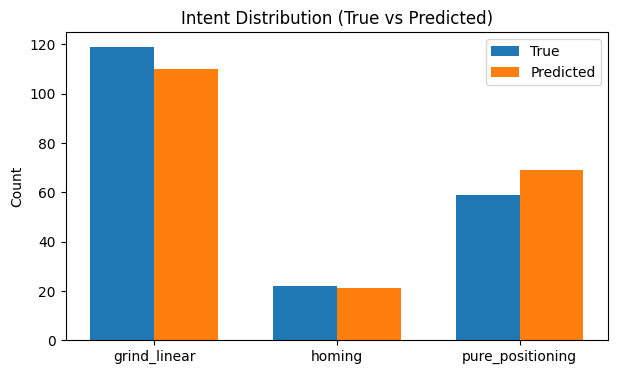

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# شمارش intent واقعی و پیش‌بینی‌شده
true_counts = pd.Series(true_intents).value_counts()
pred_counts = pd.Series(pred_intents).value_counts()

# یکسان‌سازی indexها
all_intents = sorted(set(true_counts.index) | set(pred_counts.index))
true_counts = true_counts.reindex(all_intents, fill_value=0)
pred_counts = pred_counts.reindex(all_intents, fill_value=0)

# موقعیت میله‌ها
x = range(len(all_intents))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x, true_counts.values, width, label="True")
plt.bar([i + width for i in x], pred_counts.values, width, label="Predicted")

plt.xticks([i + width/2 for i in x], all_intents)
plt.ylabel("Count")
plt.title("Intent Distribution (True vs Predicted)")
plt.legend()
plt.show()



In [ ]:
N = 200

sample_df = df.sample(n=N, random_state=42)

pred_gcodes = []
true_gcodes = list(sample_df["gcode_true"])
pred_results = []

for i, row in enumerate(sample_df.itertuples(), start=1):
    sent = row.sentence

    print(f"Evaluating {i}/{N} → {sent}")

    out = llm_predict(sent)

    # 👇 این خط فرق اصلی است
    pred_gcodes.append(out["gcode"])
    pred_results.append(out)



Evaluating 1/200 → Move the grinding wheel to X6 Z-10 for a spark-out.
Evaluating 2/200 → Place the grinding wheel to X-20.
Evaluating 3/200 → Fine cut to X-32 Z-17 
Evaluating 4/200 → Bring the tool head back to its home point
Evaluating 5/200 → Move to X-10 Z0 for inspection.
Evaluating 6/200 → Position the grinding wheel at X21 Z0.
Evaluating 7/200 → Place the grinding wheel at Z5.
Evaluating 8/200 → Place the grinding wheel to X10.
Evaluating 9/200 → Move to X-40 Z0 for inspection.
Evaluating 10/200 → Move the wheel to X9 Z-8 at F6.
Evaluating 11/200 → Cut deeply up to X-25 Z-10
Evaluating 12/200 → Return quickly to the position X0 Z0
Evaluating 13/200 → Move the wheel to X-6 Z-7 at F6.
Evaluating 14/200 → Shift the grinding wheel to X0 Z-8 for a finishing pass.
Evaluating 15/200 → Move the grinding wheel to X13 Z-16 for a light cut.
Evaluating 16/200 → Go to Z0 for a check.
Evaluating 17/200 → Move the wheel to X-8 Z-1 at F26
Evaluating 18/200 → Return immediately to the safety po

In [ ]:
print(classification_report(true_gcodes, pred_gcodes))

                          precision    recall  f1-score   support

                G00 X-10       0.00      0.00      0.00         1
             G00 X-10 Z0       0.00      0.00      0.00         0
            G00 X-13 Z10       1.00      1.00      1.00         1
             G00 X-14 Z5       1.00      1.00      1.00         1
                G00 X-15       0.00      0.00      0.00         1
            G00 X-15 Z-6       1.00      1.00      1.00         2
             G00 X-15 Z0       0.50      1.00      0.67         1
              G00 X-2 Z0       1.00      1.00      1.00         1
             G00 X-2 Z10       1.00      1.00      1.00         1
                G00 X-20       0.00      0.00      0.00         2
            G00 X-20 Z-4       0.00      0.00      0.00         0
             G00 X-20 Z0       0.00      0.00      0.00         0
                G00 X-25       0.00      0.00      0.00         1
             G00 X-25 Z0       0.50      1.00      0.67         1
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:
import re
import numpy as np

def normalize_gcode(s: str) -> str:
    if s is None:
        return ""
    s = str(s).strip().upper()
    s = re.sub(r"\s+", " ", s)   # collapse spaces
    return s

def get_val_from_gcode(g: str, letter: str):
    if g is None:
        return None
    g = normalize_gcode(g)
    m = re.search(rf"\b{letter}\s*(-?\d+(?:\.\d+)?)\b", g)
    return float(m.group(1)) if m else None

def get_F_token_from_gcode(g: str):
    """
    Returns either:
      - numeric F (float) if "F12" exists
      - label string if "F_MEDIUM" / "F_STANDARD" etc exists
      - None
    """
    if g is None:
        return None
    g = normalize_gcode(g)

    # numeric F like F6, F12, F29.5
    m = re.search(r"\bF\s*(-?\d+(?:\.\d+)?)\b", g)
    if m:
        return float(m.group(1))

    # label like F_STANDARD / F_MEDIUM / etc
    m = re.search(r"\bF_(PRECISE|SLOW|MEDIUM|FAST|STANDARD)\b", g)
    if m:
        return "F_" + m.group(1)
    return None

def intent_from_gcode(g: str):
    g = normalize_gcode(g)
    if re.match(r"^G\s*28\b", g): return "homing"
    if re.match(r"^G\s*0+(\.0+)?\b", g): return "pure_positioning"  # G0/G00
    if re.match(r"^G\s*0*1(\.0+)?\b", g): return "grind_linear"      # G1/G01
    return None

def extract_entities_from_json(out: dict):
    """
    Your LLM JSON has x_value, z_value, F_number, F_label.
    Normalize them to a comparable dict.
    """
    if out is None:
        return {"X": None, "Z": None, "F": None}

    x = out.get("x_value", None)
    z = out.get("z_value", None)
    fnum = out.get("F_number", None)
    flab = out.get("F_label", None)

    # Normalize numpy NaN -> None
    try:
        if x is not None and (isinstance(x, float) and np.isnan(x)): x = None
    except: pass
    try:
        if z is not None and (isinstance(z, float) and np.isnan(z)): z = None
    except: pass
    try:
        if fnum is not None and (isinstance(fnum, float) and np.isnan(fnum)): fnum = None
    except: pass

    # F: if numeric exists, use numeric; else use label; else None
    F = fnum if fnum is not None else flab
    return {"X": x, "Z": z, "F": F}

def extract_entities_from_gold_gcode(gold_gcode: str):
    return {
        "X": get_val_from_gcode(gold_gcode, "X"),
        "Z": get_val_from_gcode(gold_gcode, "Z"),
        "F": get_F_token_from_gcode(gold_gcode),
    }

def entities_match(pred_ent: dict, gold_ent: dict, tol=0.0):
    """
    Strict by default (tol=0.0). You can set tol=0.01 if you want float tolerance.
    """
    for k in ["X", "Z"]:
        pv, gv = pred_ent.get(k), gold_ent.get(k)
        if pv is None and gv is None:
            continue
        if (pv is None) != (gv is None):
            return False
        # numeric compare with optional tolerance
        if abs(float(pv) - float(gv)) > tol:
            return False

    # F can be float or label string or None
    pf, gf = pred_ent.get("F"), gold_ent.get("F")
    return pf == gf


In [ ]:
# --- GOLD ---
gold_intents = list(sample_df["intent"])
gold_gcodes  = [normalize_gcode(x) for x in sample_df["gcode_true"]]

# --- PRED ---
pred_intents = [r.get("intent") if isinstance(r, dict) else None for r in pred_results]
pred_gcodes  = [normalize_gcode(r.get("gcode")) if isinstance(r, dict) else "" for r in pred_results]

# G-code exact match
gcode_exact = np.mean([p == g for p, g in zip(pred_gcodes, gold_gcodes)])

# Intent accuracy (from JSON intent)
intent_acc = np.mean([p == g for p, g in zip(pred_intents, gold_intents)])

# Entity accuracy (compare X/Z/F in JSON vs gold gcode)
ent_ok = []
for pred_out, gold_g in zip(pred_results, gold_gcodes):
    pred_ent = extract_entities_from_json(pred_out if isinstance(pred_out, dict) else {})
    gold_ent = extract_entities_from_gold_gcode(gold_g)
    ent_ok.append(entities_match(pred_ent, gold_ent, tol=0.0))  # strict

entity_acc = float(np.mean(ent_ok))

# Joint accuracy (all three correct together)
joint_acc = np.mean([
    (pi == gi) and (pg == gg) and eo
    for pi, gi, pg, gg, eo in zip(pred_intents, gold_intents, pred_gcodes, gold_gcodes, ent_ok)
])

metrics = {
    "n": len(sample_df),
    "intent_accuracy": float(intent_acc),
    "entity_accuracy": float(entity_acc),
    "gcode_exact_match": float(gcode_exact),
    "joint_accuracy": float(joint_acc),
}
metrics


TypeError: entities_match() missing 1 required positional argument: 'sentence'

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics_bar(metrics: dict, title="LLM Prompt Evaluation (Test Set)"):
    labels = [
        "Intent Accuracy",
        "Entity Accuracy",
        "G-code Accuracy",
        "Joint Accuracy",
    ]

    values = [
        metrics["intent_accuracy"] * 100,
        metrics["entity_accuracy"] * 100,
        metrics["gcode_accuracy"] * 100,
        metrics["joint_accuracy"] * 100,
    ]

    plt.figure(figsize=(9, 5))
    plt.bar(labels, values)
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.ylim(0, 100)

    # value labels on bars
    for i, v in enumerate(values):
        plt.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=11)

    plt.tight_layout()
    plt.show()


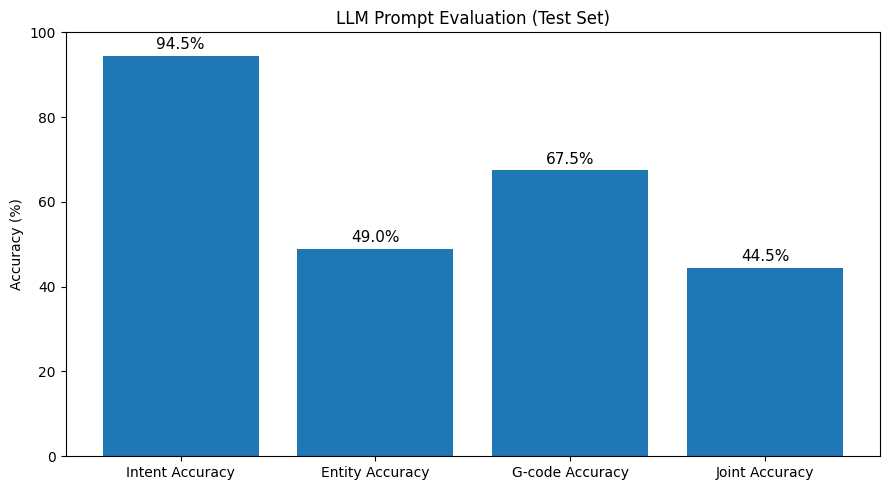

In [ ]:
plot_metrics_bar(metrics)
